
1. Estrarre le configurazioni dal nome di ciascun file.

2. Caricare i dati da ciascun file .tsv in un DataFrame pandas.

3. Combinare i dati in un unico DataFrame, aggiungendo una colonna per indicare la configurazione di ciascuna misura.

In [2]:
from pathlib import Path

def get_file_list(folder_path, pattern="*.tsv", recursive=False):
    """
    Restituisce la lista di file (percorsi stringa) nella cartella `folder_path`
    che corrispondono al glob `pattern`. Se recursive=True usa rglob().
    """
    p = Path(folder_path)
    if not p.exists():
        raise FileNotFoundError(f"Cartella non trovata: {folder_path}")
    if not p.is_dir():
        raise NotADirectoryError(f"Non è una cartella: {folder_path}")

    if recursive:
        files = sorted([f for f in p.rglob(pattern) if f.is_file()])
    else:
        files = sorted([f for f in p.glob(pattern) if f.is_file()])

    return [str(f) for f in files]

# --- Esempio di uso: impostare qui il percorso della cartella ---
folder_path = "./misure_interessanti/monotone-DAC/pixel_x6_y6"  # Sostituire con il path reale
# pattern può essere "*.tsv", "*.*", "*.txt", ecc.
file_list = get_file_list(folder_path, pattern="*.tsv", recursive=False)

print(f"Trovati {len(file_list)} file in {folder_path}")
# file_list è pronto per essere usato nelle celle successive (es. la cella che legge i file)

Trovati 3 file in ./misure_interessanti/monotone-DAC/pixel_x6_y6


In [4]:
import re
import pandas as pd


def parse_falaphel_filename(file_path):
    """Estrae parametri da nome file tipo:
        data_falaphel_prin_<timestamp><suffix_string>[_]x[_]<pixel_x>[_]y[_]<pixel_y>.tsv
    """
    file_name = Path(file_path).name
    
    # 1. Trova il suffisso e le coordinate del pixel.
    # Pattern flessibile: (...suffix) + (_?x_?) + (num) + (_?y_?) + (num) + .tsv
    # Questo copre: ...suffixx5y5.tsv E ...suffix_x_5_y_5.tsv E ...suffix_x5_y5.tsv
    m = re.search(r'(.+?)[_]?x[_]?(\d+)[_]?y[_]?(\d+)\.tsv$', file_name)

    if not m:
        return None
        
    suffix = m.group(1)
    config = {
        'pixel_x': int(m.group(2)),
        'pixel_y': int(m.group(3)),
    }
    
    # 2. dac_th (supporta 'dacth<num>' O 'dacth_<num>')
    dac_th_m = re.search(r'dacth_?(\d+)', suffix)
    config['dac_th'] = int(dac_th_m.group(1)) if dac_th_m else 0

    # 3. flag booleani (rimane invariato)
    for flag in ("cap50", "cap25", "cap_csa_load", "t_up"):
        config[flag] = 1 if flag in suffix else 0

    # 4. timestamp (opzionale)
    ts_m = re.search(r'_prin_(\d{12})', file_name)
    if ts_m:
        config['timestamp'] = ts_m.group(1)

    return config

all_data = []
if not file_list:
    print("Nessun file nella lista.")
else:
    print(f"Trovati {len(file_list)} file. Procedo a leggere e parsare...")
    for fp in file_list:
        cfg = parse_falaphel_filename(fp)
        if cfg is None:
            print(f"❌ Impossibile parsare il nome: {fp}")
            continue
        try:
            df = pd.read_csv(fp, sep='\t')
            
            # 🚨 MODIFICA QUI: Rimuovi le righe dove 'voltage' è 103
            initial_rows = len(df)
            df = df[df['voltage'] != 103]
            rows_removed = initial_rows - len(df)
            
            if rows_removed > 0:
                print(f"File {Path(fp).name}: rimosse {rows_removed} righe con voltage = 103.")

            # aggiungi colonne di configurazione
            for k, v in cfg.items():
                df[k] = v
            df['file_name'] = Path(fp).name
            all_data.append(df)
        except Exception as e:
            print(f"⚠️ Errore leggendo {fp}: {e}")

if all_data:
    df_combined = pd.concat(all_data, ignore_index=True)
    print(f"\nCombinazione completata: {len(df_combined)} righe, {len(df_combined.columns)} colonne.")
    display(df_combined.head())
else:
    print("Nessun dato caricato con successo.")

#salva il dataframe combinato in un file excel
#output_excel_path = "combined_falaphel_data.xlsx"
#df_combined.to_excel(output_excel_path, index=False)
#print(f"Dati combinati salvati in {output_excel_path}.")


Trovati 3 file. Procedo a leggere e parsare...
File data_falaphel_prin_251112_145313_cap50_t_up_dacth_12_x_6_y_6.tsv: rimosse 1 righe con voltage = 103.
File data_falaphel_prin_251112_150844_cap50_t_up_dacth_18_x_6_y_6.tsv: rimosse 1 righe con voltage = 103.
File data_falaphel_prin_251112_152413_cap50_t_up_dacth_31_x_6_y_6.tsv: rimosse 1 righe con voltage = 103.

Combinazione completata: 75 righe, 15 colonne.


,voltage,tot_avg,tot_std,toa_avg,toa_std,efficiency_tot,efficiency_toa,pixel_x,pixel_y,dac_th,cap50,cap25,cap_csa_load,t_up,file_name
0,100,4.097,0.301,13.677,0.541,1.0,1.0,6,6,12,1,0,0,1,data_falaphel_prin_251112_145313_cap50_t_up_da...
1,97,4.032,0.180,13.710,0.529,1.0,1.0,6,6,12,1,0,0,1,data_falaphel_prin_251112_145313_cap50_t_up_da...
2,94,4.000,0.000,14.097,0.473,1.0,1.0,6,6,12,1,0,0,1,data_falaphel_prin_251112_145313_cap50_t_up_da...
3,91,4.000,0.000,14.355,0.486,1.0,1.0,6,6,12,1,0,0,1,data_falaphel_prin_251112_145313_cap50_t_up_da...
4,88,3.935,0.250,14.968,0.547,1.0,1.0,6,6,12,1,0,0,1,data_falaphel_prin_251112_145313_cap50_t_up_da...


Computed fits for 3 configurations.


,dac_th,t_up,pixel_x,pixel_y,cap50,cap25,cap_csa_load,efficiency_tot_mu,efficiency_tot_sigma,efficiency_tot_status,efficiency_toa_mu,efficiency_toa_sigma,efficiency_toa_status
0,12,1,6,6,1,0,0,59.295464,1.716341,Success,59.095111,1.678366,Success
1,18,1,6,6,1,0,0,63.721846,2.126018,Success,63.379998,1.415312,Success
2,31,1,6,6,1,0,0,75.314106,2.919593,Success,74.183004,2.348317,Success


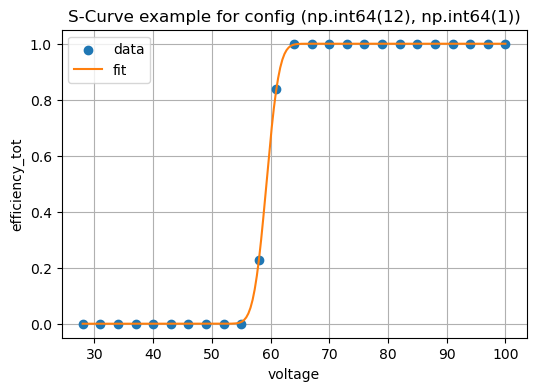

Dati combinati salvati in elaborated_falaphel_data.xlsx.


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import erf
from math import sqrt

import matplotlib.pyplot as plt

def myERF(x, mu, sigma):
    """Error function used for S-curve fits."""
    return 0.5 * (1 + erf((x - mu) / (sigma * sqrt(2))))

def fit_s_curve(data_group, grouping_keys, gname):
    """
    Fit S-curve (myERF) to efficiency columns for a single group.
    Returns a pandas.Series with grouping keys, a few constant config fields
    and fit results for 'efficiency_tot' and 'efficiency_toa'.
    """
    results = {}


    if isinstance(gname, tuple):
        for k, v in zip(grouping_keys, gname):
            results[k] = v
    else:
        results[grouping_keys[0]] = gname

    # copy a few other constant configuration columns (take first value)
    for key in ['pixel_x', 'pixel_y', 'cap50', 'cap25', 'cap_csa_load']:
        if key in data_group.columns:
            results[key] = data_group[key].iloc[0]

    cols_to_fit = ["efficiency_tot", "efficiency_toa"]
    for col in cols_to_fit:
        valid = data_group[["voltage", col]].dropna()
        if len(valid) < 4:
            results[f'{col}_mu'] = np.nan
            results[f'{col}_sigma'] = np.nan
            results[f'{col}_status'] = "Not enough data"
            continue

        xdata = valid["voltage"].values.astype(float)
        ydata = valid[col].values.astype(float)

        guess = [np.median(xdata), max(1.0, (xdata.max() - xdata.min()) / 4.0)]
        try:
            popt, pcov = curve_fit(
                myERF,
                xdata,
                ydata,
                p0=guess,
                bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                maxfev=20000
            )
            fit_mu, fit_sigma = popt
            results[f'{col}_mu'] = float(fit_mu)
            results[f'{col}_sigma'] = float(fit_sigma)
            results[f'{col}_status'] = "Success"
        except Exception as e:
            results[f'{col}_mu'] = np.nan
            results[f'{col}_sigma'] = np.nan
            results[f'{col}_status'] = f"Fit failed: {e}"

    return pd.Series(results)

# --- Apply fit to each unique configuration in df_combined ---
grouping_keys = ['dac_th', 't_up']

results = []
for name, grp in df_combined.groupby(grouping_keys, dropna=False):
    # ensure grp.name is available to fit_s_curve (pandas sets it)
    res = fit_s_curve(grp, grouping_keys, name)
    results.append(res)

df_fit_results = pd.DataFrame(results)
if not df_fit_results.empty:
    df_fit_results = df_fit_results.sort_values(by=grouping_keys).reset_index(drop=True)

# Quick display
print(f"Computed fits for {len(df_fit_results)} configurations.")
display(df_fit_results.head())

# Optional: example plot for first successful group (efficiency_tot)
first_ok = None
for name, grp in df_combined.groupby(grouping_keys, dropna=False):
    valid = grp[["voltage", "efficiency_tot"]].dropna()
    if len(valid) >= 4:
        first_ok = (name, grp)
        break

if first_ok is not None:
    name, grp = first_ok
    x = np.linspace(grp.voltage.min(), grp.voltage.max(), 200)
    # find corresponding fit params in df_fit_results
    mask = (df_fit_results['dac_th'] == (name[0] if isinstance(name, tuple) else name))
    if 't_up' in df_fit_results.columns and isinstance(name, tuple):
        mask &= (df_fit_results['t_up'] == name[1])
    row = df_fit_results[mask].iloc[0] if mask.any() else None
    plt.figure(figsize=(6,4))
    plt.scatter(grp.voltage, grp.efficiency_tot, label='data', zorder=2)
    if row is not None and pd.notna(row.get('efficiency_tot_mu')) and pd.notna(row.get('efficiency_tot_sigma')):
        plt.plot(x, myERF(x, row['efficiency_tot_mu'], row['efficiency_tot_sigma']), color='C1', label='fit', zorder=3)
    plt.xlabel('voltage')
    plt.ylabel('efficiency_tot')
    plt.title(f'S-Curve example for config {name}')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No group with enough points found for example plot.")


# salva il dataframe combinato in un file excel
#output_excel_path = "elaborated_falaphel_data.xlsx"
#df_combined.to_excel(output_excel_path, index=False)
#print(f"Dati combinati salvati in {output_excel_path}.")

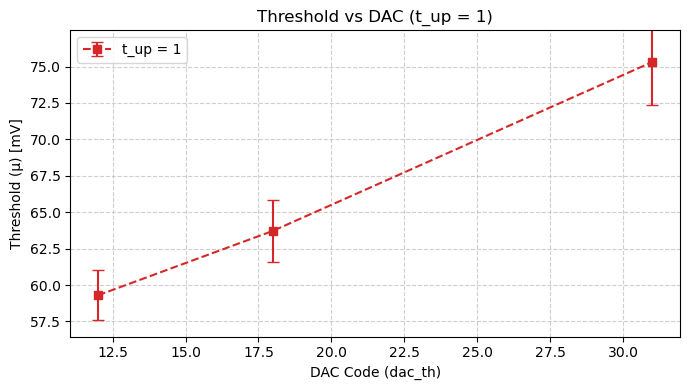

Dati per il plot salvati in 'threshold_vs_dac_tup1.tsv'.


In [ ]:
# Importa la libreria se non è già stata importata
# import matplotlib.pyplot as plt
# import pandas as pd

## Plot solo per df_tup1 (t_up = 1) ##

# 1. Prepara i dati ordinati
# df_tup1 deve essere un DataFrame di pandas contenente 'dac_th', 'efficiency_tot_mu', 
# 'efficiency_tot_sigma', 'efficiency_toa_mu' e 'efficiency_toa_sigma'.
df1 = df_fit_results.sort_values('dac_th')
color_tup1 = 'tab:red'

# 2. Calcola i limiti dell'asse Y (ylimits) basandosi solo su df1
ymins = []
ymaxs = []

if not df1.empty:
    # Si usa efficiency_toa per i limiti Y per coerenza con il codice originale
    ymin = (df1['efficiency_toa_mu'] - df1['efficiency_toa_sigma']).min()
    ymax = (df1['efficiency_toa_mu'] + df1['efficiency_toa_sigma']).max()
    ymins.append(ymin); ymaxs.append(ymax)

ymin = min(ymins) if ymins else None
ymax = max(ymaxs) if ymaxs else None
ylimits = None

if ymin is not None and ymax is not None:
    # Aggiunge un padding del 5%
    ypad = 0.05 * (ymax - ymin) if (ymax - ymin) > 0 else 1.0
    ylimits = (ymin - ypad, ymax + ypad)

# 3. Genera il Plot per t_up = 1
if not df1.empty:
    fig1, ax1 = plt.subplots(figsize=(7,4))
    ax1.errorbar(
        df1['dac_th'],                 # Asse X: DAC Code
        df1['efficiency_tot_mu'],      # Asse Y: Threshold (Media TOT)
        yerr=df1['efficiency_tot_sigma'], # Barre di errore: Sigma TOT
        fmt='s--',                     # Marker quadrato, linea tratteggiata
        capsize=4,
        color=color_tup1,
        label='t_up = 1'
    )
    ax1.set_xlabel('DAC Code (dac_th)')
    ax1.set_ylabel('Threshold (μ) [mV]')
    ax1.set_title('Threshold vs DAC (t_up = 1)')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()
    
    if ylimits:
        ax1.set_ylim(ylimits)
        
    plt.tight_layout()
    #fig1.savefig('threshold_vs_dac_tup1.png', dpi=150)
    plt.show()
else:
    print("Nessun dato in df_tup1 da plottare.")

# 4. Salva i dati anche in formato TSV
#df1.to_csv('threshold_vs_dac_tup1.tsv', sep='\t', index=False)
#print("Dati per il plot salvati in 'threshold_vs_dac_tup1.tsv'.")

In [ ]:
# Plot threshold (efficiency_tot_mu) vs DAC for t_up = 0 and t_up = 1 in two separate figures.
# Uses existing variables: df_tup0, df_tup1, color_tup0, color_tup1, plt

# prepare sorted data
df0 = df_tup0.sort_values('dac_th')
df1 = df_tup1.sort_values('dac_th')

# compute common y-limits if possible for consistent comparison
ymins = []
ymaxs = []
for df in (df0, df1):
    if not df.empty:
        ymin = (df['efficiency_toa_mu'] - df['efficiency_toa_sigma']).min()
        ymax = (df['efficiency_toa_mu'] + df['efficiency_toa_sigma']).max()
        ymins.append(ymin); ymaxs.append(ymax)

ymin = min(ymins) if ymins else None
ymax = max(ymaxs) if ymaxs else None
if ymin is not None and ymax is not None:
    ypad = 0.05 * (ymax - ymin) if (ymax - ymin) > 0 else 1.0
    ylimits = (ymin - ypad, ymax + ypad)
else:
    ylimits = None

# plot for t_up = 0
if not df0.empty:
    fig0, ax0 = plt.subplots(figsize=(7,4))
    ax0.errorbar(
        df0['dac_th'],
        df0['efficiency_tot_mu'],
        yerr=df0['efficiency_toa_sigma'],
        fmt='o-',
        capsize=4,
        color=color_tup0,
        label='t_up = 0'
    )
    ax0.set_xlabel('DAC Code (dac_th)')
    ax0.set_ylabel('Threshold (μ) [mV]')
    ax0.set_title('Threshold vs DAC (t_up = 0)')
    ax0.grid(True, linestyle='--', alpha=0.6)
    ax0.legend()
    if ylimits:
        ax0.set_ylim(ylimits)
    plt.tight_layout()
    fig0.savefig('threshold_vs_dac_tup0.png', dpi=150)
    plt.show()
else:
    print("No data for t_up = 0 to plot.")

# plot for t_up = 1
if not df1.empty:
    fig1, ax1 = plt.subplots(figsize=(7,4))
    ax1.errorbar(
        df1['dac_th'],
        df1['efficiency_tot_mu'],
        yerr=df1['efficiency_tot_sigma'],
        fmt='s--',
        capsize=4,
        color=color_tup1,
        label='t_up = 1'
    )
    ax1.set_xlabel('DAC Code (dac_th)')
    ax1.set_ylabel('Threshold (μ) [mV]')
    ax1.set_title('Threshold vs DAC (t_up = 1)')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()
    if ylimits:
        ax1.set_ylim(ylimits)
    plt.tight_layout()
    fig1.savefig('threshold_vs_dac_tup1.png', dpi=150)
    plt.show()
else:
    print("No data for t_up = 1 to plot.")


# salva i due plot anche come file tsv pronto per il plotter esterno
df0.to_csv('threshold_vs_dac_tup0.tsv', sep='\t', index=False)
df1.to_csv('threshold_vs_dac_tup1.tsv', sep='\t', index=False)
print("Dati per i plot salvati in 'threshold_vs_dac_tup0.tsv' e 'threshold_vs_dac_tup1.tsv'.")

NameError: name 'df_tup0' is not defined

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\s'
C:\Users\andre\AppData\Local\Temp\ipykernel_64772\4017094024.py:31: SyntaxWarning: invalid escape sequence '\m'
  label='Threshold Tot ($\mu$) - $t_{up}=0$'
C:\Users\andre\AppData\Local\Temp\ipykernel_64772\4017094024.py:42: SyntaxWarning: invalid escape sequence '\m'
  label='Threshold Tot ($\mu$) - $t_{up}=1$'
C:\Users\andre\AppData\Local\Temp\ipykernel_64772\4017094024.py:47: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Threshold ($\mu$) [mV]")
C:\Users\andre\AppData

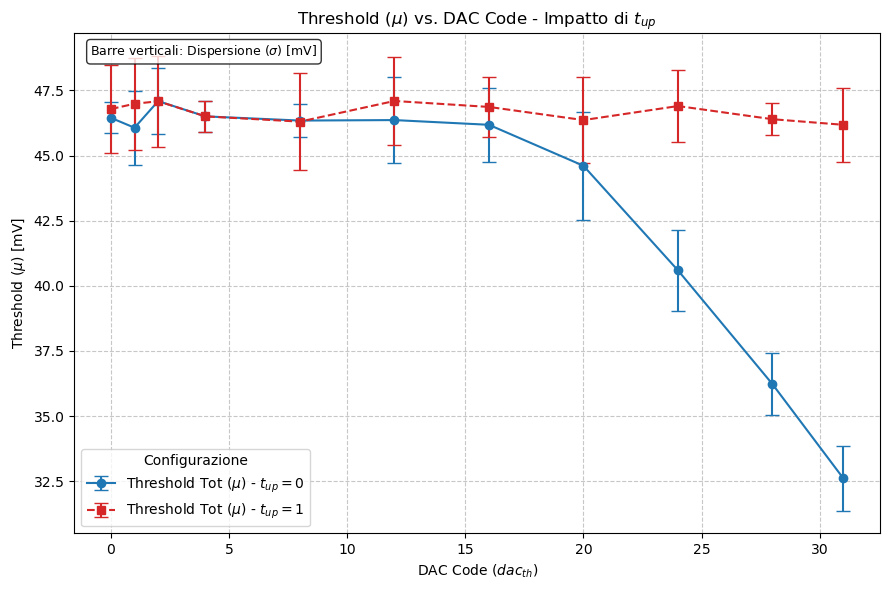

In [14]:
# ASSUMIAMO CHE df_fit_results ESISTA E SIA STATO CREATO CORRETTAMENTE

# 1. Preparazione dei dati: Filtra per i fit riusciti
df_filtered = df_fit_results[
    (df_fit_results['efficiency_tot_status'] == 'Success')
].copy()

# Ordina per dac_th per un plotting corretto
df_filtered = df_filtered.sort_values(by='dac_th')

# Separa i dati per la configurazione t_up
df_tup0 = df_filtered[df_filtered['t_up'] == 0]
df_tup1 = df_filtered[df_filtered['t_up'] == 1]

# 2. Creazione del plot
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

# Colori
color_tup0 = 'tab:blue'
color_tup1 = 'tab:red'

# 3. Plot t_up=0 
# X: dac_th, Y: efficiency_tot_mu, YERR: efficiency_tot_sigma
ax.errorbar(
    df_tup0['dac_th'],
    df_tup0['efficiency_tot_mu'],
    yerr=df_tup0['efficiency_tot_sigma'],
    fmt='o-', # Punti e linea solida
    capsize=5,
    color=color_tup0,
    label='Threshold Tot ($\mu$) - $t_{up}=0$'
)

# 4. Plot t_up=1 
ax.errorbar(
    df_tup1['dac_th'],
    df_tup1['efficiency_tot_mu'],
    yerr=df_tup1['efficiency_tot_sigma'],
    fmt='s--', # Punti quadrati e linea tratteggiata
    capsize=5,
    color=color_tup1,
    label='Threshold Tot ($\mu$) - $t_{up}=1$'
)

# 5. Personalizzazione del plot
ax.set_xlabel("DAC Code ($dac_{th}$)")
ax.set_ylabel("Threshold ($\mu$) [mV]")
ax.set_title("Threshold ($\mu$) vs. DAC Code - Impatto di $t_{up}$")
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(title='Configurazione')

# Aggiungi una nota sulle barre di errore
ax.text(
    0.02, 0.98, 
    "Barre verticali: Dispersione ($\sigma$) [mV]", 
    transform=ax.transAxes, 
    fontsize=9, 
    verticalalignment='top', 
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
)

plt.tight_layout()
fig.savefig("threshold_vs_dac_tup_comparison.png")